### Instala las librerias sino las tiene :)

In [11]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl jupyter

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached notebook-7.5.3-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.0-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.5.4-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\luigy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### 1. Importar librerías

In [2]:
#Esto lo pongo solo para informativo
import sys
print(sys.executable)

#Instalamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


C:\Users\luigy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


### 2. Cargar dataset

In [3]:
df = pd.read_excel("../data/online_retail.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 3. Análisis Exploratorio de Datos (EDA)

In [4]:
# Mostrar información general del dataset
# Permite visualizar el número de registros, tipos de datos y valores no nulos
df.info()

# Mostrar estadísticas descriptivas de las variables numéricas
# Incluye media, desviación estándar, valores mínimos y máximos
df.describe()

# Verificar la cantidad de valores nulos por columna
# Es importante identificar si existen datos faltantes que deban limpiarse
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

### 4. Limpieza y Preprocesamiento de Datos

#### 4.1 Eliminación de registros sin identificación de cliente

In [5]:
# Eliminar registros sin Customer ID
df = df.dropna(subset=["Customer ID"])

# Verificar nueva dimensión del dataset
df.shape

(417534, 8)

#### 4.2 Eliminación de devoluciones

In [6]:
# Eliminar facturas que comienzan con "C"
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Verificar dimensión nuevamente
df.shape

(407695, 8)

#### 4.3 Crear variable TotalPrice

In [7]:
# Crear variable de valor total
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


#### 4.4 Verificación final después de limpieza

In [8]:
df.describe()
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

### 5. Construcción del Modelo RFM

#### 5.1 Definición de la fecha de referencia

In [9]:
# Definir fecha de referencia
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2010-12-10 20:01:00')

#### 5.2 Construcción de la tabla RFM

In [10]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

# Renombrar columnas
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


#### 5.3 Verificación de la matriz RFM

In [11]:
rfm.describe()

,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000
mean,91.269124,4.454103,2047.288659
std,96.943482,8.168658,8912.523243
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.950000
50%,53.000000,2.000000,705.550000
75%,136.000000,5.000000,1722.802500
max,374.000000,205.000000,349164.350000


### 6. Escalamiento de Variables

#### 6.1 Justificación

Las variables Recency, Frequency y Monetary tienen escalas muy diferentes:

Recency está en días.

Frequency es número de compras.

Monetary puede llegar a cientos de miles.

Si no escalamos, el modelo dará más peso a Monetary y el clustering será incorrecto.

#### 6.2 Aplicar StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

#### 6.3 Convertir a DataFrame

In [13]:
rfm_scaled = pd.DataFrame(rfm_scaled, 
                          columns=["Recency", "Frequency", "Monetary"],
                          index=rfm.index)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.760643,0.801436,-0.187895
12347.0,-0.910627,-0.300464,-0.081240
12348.0,-0.178157,-0.422897,-0.204806
12349.0,-0.497968,-0.178031,0.070005
12351.0,-0.828095,-0.422897,-0.195967


#### 6.4 Verificación

In [14]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.314000e+03,4.314000e+03,4.314000e+03
mean,8.647078e-18,4.282362e-17,1.647062e-18
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.312600e-01,-4.228973e-01,-2.297358e-01
25%,-7.558798e-01,-4.228973e-01,-1.951793e-01
50%,-3.948028e-01,-3.004640e-01,-1.505628e-01
75%,4.614654e-01,6.683599e-02,-3.641211e-02
max,2.916789e+00,2.455350e+01,3.895163e+01


### 7. Aplicación de K-Means

#### 7.1 Método del Codo

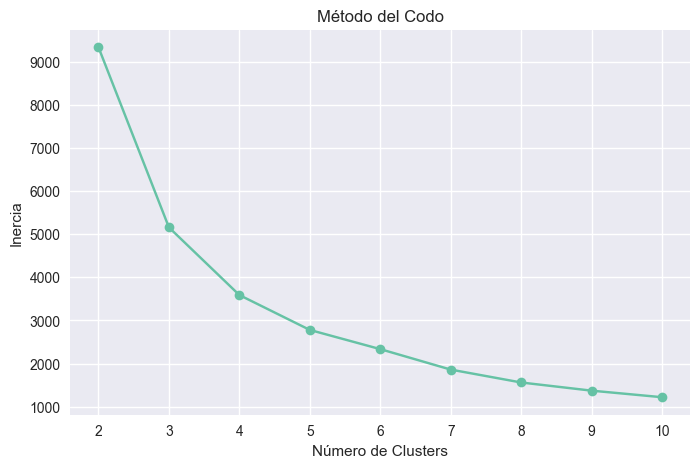

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")

plt.savefig("../visualizations/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()



#### 7.2 Aplicar K-Means con k óptimo y Ver tamaño de cada cluster

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

rfm["Cluster"].value_counts()


Cluster
0    3207
1    1049
3      53
2       5
Name: count, dtype: int64

#### 7.4 Perfil promedio por cluster 

In [35]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.996882,4.469598,1743.129790
1,243.086749,1.658723,595.746486
2,5.600000,113.600000,215543.670000
3,15.433962,48.547170,29040.181566


### 8. Validación del número óptimo de clusters (Silhouette Score)

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])
score

0.6099729618321483

### 9. Aplicación de DBSCAN

In [37]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
rfm["Cluster_DBSCAN"] = dbscan.fit_predict(rfm_scaled)

rfm["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
 0    4277
-1      37
Name: count, dtype: int64

### 10. Reducción de dimensionalidad (PCA)

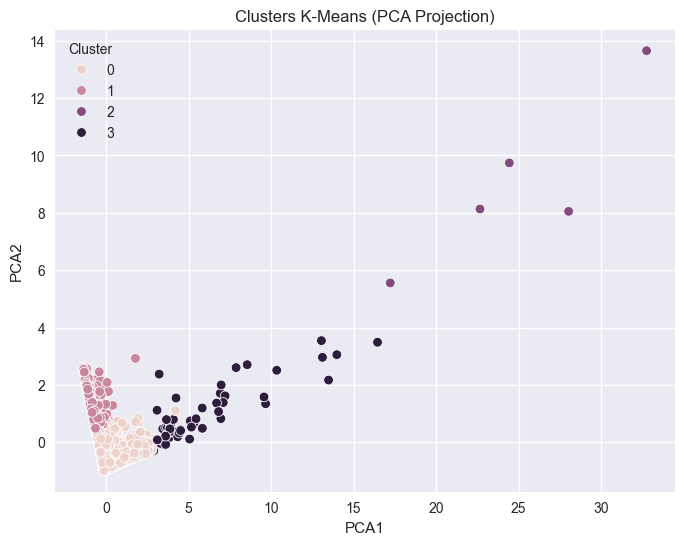

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:,0]
rfm["PCA2"] = rfm_pca[:,1]

#Visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster")
plt.title("Clusters K-Means (PCA Projection)")
plt.show()


### 11. t-SNE (detección no lineal)

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
rfm_tsne = tsne.fit_transform(rfm_scaled)

rfm["TSNE1"] = rfm_tsne[:,0]
rfm["TSNE2"] = rfm_tsne[:,1]

### 12. Comparación entre Modelos de Clustering

Se aplicaron dos algoritmos de aprendizaje no supervisado: K-Means y DBSCAN, con el objetivo de segmentar clientes a partir de variables RFM (Recency, Frequency y Monetary).

---

#### K-Means

El modelo K-Means identificó 4 clusters claramente diferenciados:

- Un grupo grande de clientes activos de valor medio.
- Un grupo de clientes inactivos o de bajo valor.
- Un grupo pequeño de clientes premium.
- Un grupo extremadamente pequeño de clientes VIP con gasto y frecuencia muy elevados.

Ventajas observadas:
- Segmentación clara y fácilmente interpretable.
- Permite caracterizar perfiles de clientes con métricas promedio.
- Adecuado cuando se desea dividir el mercado en segmentos bien definidos.

Limitaciones:
- Sensible a outliers (detectó clusters muy pequeños debido a clientes con gasto extremadamente alto).
- Requiere definir previamente el número de clusters.

---

#### DBSCAN

DBSCAN no requiere definir el número de clusters previamente y es capaz de detectar puntos considerados ruido.

Ventajas observadas:
- Detecta outliers de manera explícita.
- Puede identificar estructuras de datos no esféricas.
- Más robusto frente a valores extremos.

Limitaciones:
- Sensible a la elección de parámetros (eps y min_samples).
- Puede generar un único cluster dominante si la densidad de datos no está claramente separada.
- Menos interpretable para segmentación comercial tradicional.

---

#### Comparación Técnica

- K-Means generó segmentos más interpretables desde el punto de vista de negocio.
- DBSCAN mostró mayor capacidad para identificar clientes extremadamente atípicos como ruido.
- La estructura de los datos RFM parece ajustarse mejor a un modelo basado en centroides como K-Means.
- La presencia de clusters muy pequeños en K-Means indica alta dispersión en la variable Monetary.

---

#### Modelo Recomendado

Para fines de segmentación comercial y estrategias de marketing, K-Means resulta más adecuado debido a su interpretabilidad y facilidad para caracterizar perfiles de clientes.

DBSCAN puede utilizarse como complemento para detección de clientes atípicos o análisis de anomalías.

---

#### Conclusión General

Ambos modelos aportan valor desde perspectivas distintas.  
K-Means es más útil para segmentación estratégica de clientes, mientras que DBSCAN es más apropiado para detección de comportamientos extremos o análisis de anomalías.

La elección final del modelo depende del objetivo del negocio: segmentación estructurada o identificación de outliers.


### Visualización de Clusters con PCA

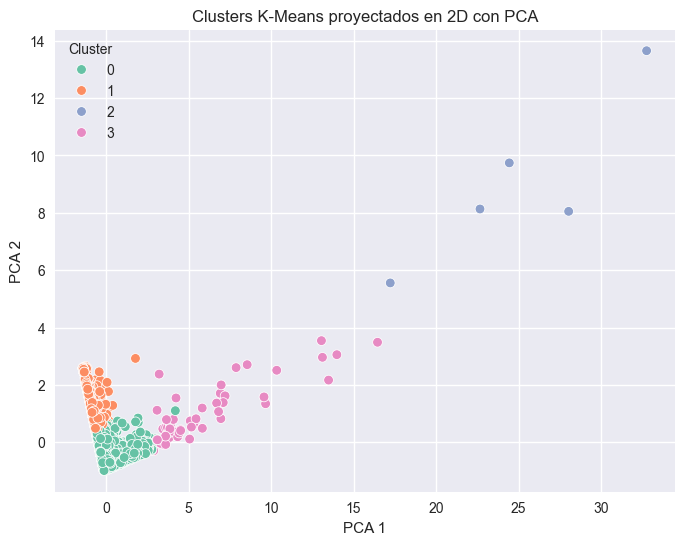

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Agregar al dataframe
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

# Graficar
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.title("Clusters K-Means proyectados en 2D con PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Guardar imagen
plt.savefig("../visualizations/pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()



### Visualización con t-SNE

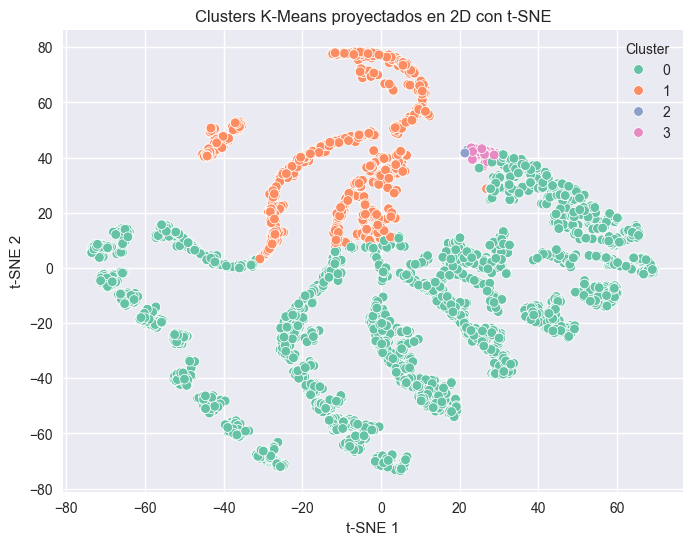

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
rfm_tsne = tsne.fit_transform(rfm_scaled)

rfm["TSNE1"] = rfm_tsne[:, 0]
rfm["TSNE2"] = rfm_tsne[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="TSNE1", y="TSNE2", hue="Cluster", palette="Set2")
plt.title("Clusters K-Means proyectados en 2D con t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Guardar imagen
plt.savefig("../visualizations/tsne_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

